In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
from snntorch import utils
from sklearn.preprocessing import LabelEncoder

In [ ]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [100]:
from snntorch import spikegen

class CustomDatasetSpike(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_steps=8, tau=1, threshold=0.3):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.num_steps = num_steps
        self.tau = tau
        self.threshold = threshold

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            img = spikegen.latency(img, num_steps=self.num_steps, tau=self.tau, threshold=self.threshold, normalize=True, linear=True, clip=True)
            return img, label


In [ ]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test1.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val1.csv")

In [ ]:
val_df.head()

In [ ]:
# shuffle val and test
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [101]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_566053.png,1
1,image_1260895.png,1
2,image_2675864.png,1
3,image_5798756.png,1
4,image_5737705.png,1


In [102]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

train_dataset = CustomDatasetSpike(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
val_dataset = CustomDatasetSpike(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [103]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [104]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Notes
1. With initial architecture and 4 steps of training, the model achieved 0.93 accuracy on the test set.
2. 3 layer reduced the accuracy to 0.92. reverted back to 4 layers. and using 2nd conv2d output as 64 and no padding instead of 32 and using a transform normalize

In [ ]:
class BasicSNN(nn.Module):
    def __init__(self, beta=1, num_steps=4, num_classes=2):
        super(BasicSNN, self).__init__()

        self.num_steps = num_steps
        self.num_classes = num_classes
        self.spike_grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=4)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=2, stride=2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)


        # flattened_size = 32 * (32 // 4) * (32 // 4)

        self.fc1 = nn.Linear(32, self.num_classes)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=self.spike_grad, threshold=0.3)

        self.spk1 = self.spk2 = None
        self.mem1 = self.mem2 = None


    def forward(self, x):
        # x shape: [batch_size, num_steps, C, H, W]
        x = x.permute(1, 0, 2, 3, 4)  # New shape: [num_steps, batch_size, C, H, W]
        
        mem1 = self.lif1.reset_mem()
        mem2 = self.lif2.reset_mem()
        mem3 = self.lif3.reset_mem()

        spk_rec = []
        mem_rec = []

        spk1_rec = []
        spk2_rec = []
        mem1_rec = []
        mem2_rec = []

        for step in range(self.num_steps):
            x_step = x[step]  # [batch_size, C, H, W] for current timestep

            # Layer 1
            cur1 = self.conv1(x_step)
            cur1 = F.max_pool2d(cur1, 2)  # Optional pooling
            spike1, mem1 = self.lif1(cur1, mem1)

            # Layer 2
            cur2 = self.conv2(spike1)
            cur2 = F.max_pool2d(cur2, 2)  # Optional pooling
            spike2, mem2 = self.lif2(cur2, mem2)

            # print(spike2.shape)
            # print(spike2.flatten(1).shape)

            # Classifier
            cur3 = self.fc1(spike2.flatten(1))
            spike3, mem3 = self.lif3(cur3, mem3)


            spk1_rec.append(spike1)
            spk2_rec.append(spike2)
            mem1_rec.append(mem1)
            mem2_rec.append(mem2)

            spk_rec.append(spike3)
            mem_rec.append(mem3)

        self.spk1 = torch.stack(spk1_rec, dim=0)
        self.spk2 = torch.stack(spk2_rec, dim=0)
        self.mem1 = torch.stack(mem1_rec, dim=0)
        self.mem2 = torch.stack(mem2_rec, dim=0)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

In [ ]:
dummy = torch.randn(1, 25, 1, 32, 32)
model = BasicSNN()
out, _ = model(dummy)

model.spk1.shape, model.spk2.shape, out.shape

For `torch.stack`, the `dim` affects the output of the function.
1. `dim=1` -> shape: `[batch_size, time_step, output_neurons]`
2. `dim=0` -> shape: `[time_step, batch_size, output_neurons]`
3. `dim=-1` -> shape: `[batch_size, output_neurons, time_step]`


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_class_metrics(y_true, y_pred):

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'benign': {
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [98]:
# Helper function to get predictions based on first spike timing
def get_predictions_from_spikes(spk_out):
    device = spk_out.device

    # Debug: Check if we're getting spikes for both classes
    # has_spikes = spk_out.sum(dim=0).bool()
    # class0_has_spikes = has_spikes[:, 0].any().item()
    # class1_has_spikes = has_spikes[:, 1].any().item()
    # print(f"Class 0 has spikes: {class0_has_spikes}, Class 1 has spikes: {class1_has_spikes}")
    
    # convert spk_out into first spike timing
    spk_time = (
        spk_out.transpose(0, -1)
        * (torch.arange(0, spk_out.size(0)).detach().to(device) + 1)
    ).transpose(0, -1)

    # Extract first spike time
    first_spike_time = torch.zeros_like(spk_time[0])
    for step in range(spk_time.size(0)):
        first_spike_time += (
            spk_time[step] * ~first_spike_time.bool()
        )

    # Override element 0 (no spike) with shadow spike at final time step
    first_spike_time += ~first_spike_time.bool() * (spk_time.size(0))
    first_spike_time -= 1  # fix offset

    # Get class with earliest spike
    _, preds = first_spike_time.min(1)
    return preds

In [ ]:
def train_model(train_dataloader, val_dataloader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=50, model_savepath=None, device="cuda", dt_ms=1.0):
    # Initialize model
    model = BasicSNN(num_steps=8).to(device)
    
    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, 
                                 weight_decay=weight_decay if weight_decay else 0,
                                 betas=(0.9, 0.999))
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=num_epochs // 5, T_mult=1, eta_min=1e-6, last_epoch=-1)

    # Initialize metrics tracking dictionary
    metrics = {
        'train': {
            'loss': [],           # Per batch loss
            'avg_loss': [],       # Per epoch average loss
            'acc': [],            # Per epoch accuracy
            'f1': [],             # Per epoch overall F1
            'class_metrics': [],  # Per epoch class-specific metrics
        },
        'val': {
            'loss': [],
            'avg_loss': [],
            'acc': [],
            'f1': [],
            'class_metrics': [],
        },
        # Spike statistics
        'spike_stats': {
            'train': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'val': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'firing_rate_stability': [], # General stability metric
        }
    }

    best_val_f1 = -1.0  # Track best F1 score instead of loss
    best_model_state = None
    neuron_cache = {'layer1': None, 'layer2': None, 'output': None}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # --- TRAINING PHASE ---
        model.train()
        # Per-epoch tracking
        epoch_data = {
            'train_loss': 0,
            'train_correct': 0.0,
            'train_total': 0,
            'spike_count': 0,
            'active_neurons': 0,
            'total_neurons': 0,
            'total_possible': 0,
            'train_preds': [],
            'train_targets': [],
            'sum_mem': 0.0,
            'sum_sq_mem': 0.0,
            'total_mem_samples': 0,
            'proximity_sum': 0.0,
            'proximity_sq_sum': 0.0,
            'proximity_samples': 0,
        }

        for data, targets in tqdm(train_dataloader, desc="Training"):
            data, targets = data.to(device), targets.to(device)
            utils.reset(model)

            # Forward pass
            spk_rec, mem_rec = model(data)

            # Calculate neuron counts once
            if neuron_cache['layer1'] is None:
                with torch.no_grad():
                    neuron_cache['layer1'] = model.spk1[0, 0].numel()
                    neuron_cache['layer2'] = model.spk2[0, 0].numel()
                    neuron_cache['output'] = spk_rec.size(-1)

            # Loss calculation
            loss = loss_fn(spk_rec, targets)
            epoch_data['train_loss'] += loss.item()
            metrics['train']['loss'].append(loss.item())

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- METRICS CALCULATION ---
            with torch.no_grad():
                # Accuracy using latency coding
                acc = SF.accuracy_temporal(spk_rec, targets)
                epoch_data['train_correct'] += acc * data.size(0)
                epoch_data['train_total'] += data.size(0)

                # Predictions for F1 using latency coding
                preds = get_predictions_from_spikes(spk_rec)
                epoch_data['train_preds'].append(preds.cpu())
                epoch_data['train_targets'].append(targets.cpu())

                # Spike statistics
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                batch_spike_count = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                epoch_data['spike_count'] += batch_spike_count

                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                total_batch_neurons = (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size * time_steps
                epoch_data['total_neurons'] += total_batch_neurons

                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                epoch_data['active_neurons'] += active1 + active2 + active3
                epoch_data['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size

                # Membrane statistics
                if mem_rec is not None:
                    output_layer_mem = mem_rec.detach()

                    layer1_mem = model.mem1.detach()
                    layer2_mem = model.mem2.detach()


                    mem_tensor = torch.cat([output_layer_mem.flatten(), layer1_mem.flatten(), layer2_mem.flatten()])
                    
                    mem_tensor = mem_rec.detach()
                    epoch_data['sum_mem'] += mem_tensor.sum().item()
                    epoch_data['sum_sq_mem'] += (mem_tensor**2).sum().item()
                    epoch_data['total_mem_samples'] += mem_tensor.numel()

                    proximity = torch.abs(mem_tensor - 0.3)
                    epoch_data['proximity_sum'] += proximity.sum().item()
                    epoch_data['proximity_sq_sum'] += (proximity**2).sum().item()
                    epoch_data['proximity_samples'] += proximity.numel()

        # --- EPOCH TRAINING METRICS ---
        avg_train_loss = epoch_data['train_loss'] / len(train_dataloader)
        metrics['train']['avg_loss'].append(avg_train_loss)
        
        train_acc = epoch_data['train_correct'] / epoch_data['train_total'] if epoch_data['train_total'] > 0 else 0.0
        metrics['train']['acc'].append(train_acc)

        # Calculate F1 score and class-specific metrics
        train_preds = torch.cat(epoch_data['train_preds']).numpy() if len(epoch_data['train_preds']) > 0 else np.array([])
        train_targets = torch.cat(epoch_data['train_targets']).numpy() if len(epoch_data['train_targets']) > 0 else np.array([])
        
        # Overall F1 score (binary average)
        train_f1 = f1_score(train_targets, train_preds, average='weighted') if len(train_preds) > 0 else 0.0
        metrics['train']['f1'].append(train_f1)
        
        # Calculate class-specific metrics
        if len(train_preds) > 0:
            train_class_metrics = calculate_class_metrics(train_targets, train_preds)
            metrics['train']['class_metrics'].append(train_class_metrics)
        else:
            train_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            metrics['train']['class_metrics'].append(train_class_metrics)

        # Spike metrics
        avg_spikes_per_neuron = epoch_data['spike_count'] / epoch_data['total_neurons'] if epoch_data['total_neurons'] > 0 else 0.0
        active_percent = (epoch_data['active_neurons'] / epoch_data['total_possible']) * 100 if epoch_data['total_possible'] > 0 else 0.0
        
        metrics['spike_stats']['train']['avg_spikes_per_neuron'].append(avg_spikes_per_neuron)
        metrics['spike_stats']['train']['spike_rate_hz'].append(avg_spikes_per_neuron * (1000 / dt_ms))
        metrics['spike_stats']['train']['spike_count'].append(epoch_data['spike_count'])
        metrics['spike_stats']['train']['active_neurons_percent'].append(active_percent)

        # Membrane metrics
        if epoch_data['total_mem_samples'] > 0:
            avg_mem = epoch_data['sum_mem'] / epoch_data['total_mem_samples']
            std_mem = np.sqrt((epoch_data['sum_sq_mem'] / epoch_data['total_mem_samples']) - avg_mem**2)
        else:
            avg_mem = std_mem = 0.0
        metrics['spike_stats']['train']['membrane_potential_avg'].append(avg_mem)
        metrics['spike_stats']['train']['membrane_potential_std'].append(std_mem)

        # Threshold proximity
        if epoch_data['proximity_samples'] > 0:
            avg_prox = epoch_data['proximity_sum'] / epoch_data['proximity_samples']
            std_prox = np.sqrt((epoch_data['proximity_sq_sum'] / epoch_data['proximity_samples']) - avg_prox**2)
        else:
            avg_prox = std_prox = 0.0
        metrics['spike_stats']['train']['threshold_proximity_avg'].append(avg_prox)
        metrics['spike_stats']['train']['threshold_proximity_std'].append(std_prox)

        print(f"Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Benign - P: {train_class_metrics['benign']['precision']:.4f}, R: {train_class_metrics['benign']['recall']:.4f}, F1: {train_class_metrics['benign']['f1']:.4f}")
        print(f"Malicious - P: {train_class_metrics['malicious']['precision']:.4f}, R: {train_class_metrics['malicious']['recall']:.4f}, F1: {train_class_metrics['malicious']['f1']:.4f}")
        print(f"Spikes/Neuron: {avg_spikes_per_neuron:.4f} ({avg_spikes_per_neuron*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: {active_percent:.1f}%")
        print("-" * 50)

        # --- VALIDATION PHASE ---
        with torch.no_grad():
            model.eval()
            # Per-epoch validation tracking
            val_data = {
                'val_loss': 0,
                'val_correct': 0.0,
                'val_total': 0,
                'spike_count': 0,
                'total_neurons': 0,
                'active_neurons': 0,
                'total_possible': 0,
                'val_preds': [],
                'val_targets': [],
                'sum_mem': 0.0,
                'sum_sq_mem': 0.0,
                'total_mem_samples': 0,
                'proximity_sum': 0.0,
                'proximity_sq_sum': 0.0,
                'proximity_samples': 0,
            }
            
            for data, targets in tqdm(val_dataloader, desc="Validation"):
                data, targets = data.to(device), targets.to(device)
                utils.reset(model)

                spk_rec, mem_rec = model(data)

                # Loss and accuracy
                loss = loss_fn(spk_rec, targets)
                val_data['val_loss'] += loss.item()
                metrics['val']['loss'].append(loss.item())

                # Use latency coding for accuracy
                acc = SF.accuracy_temporal(spk_rec, targets)
                val_data['val_correct'] += acc * data.size(0)
                val_data['val_total'] += data.size(0)

                # Predictions for F1 using latency coding
                preds = get_predictions_from_spikes(spk_rec)
                val_data['val_preds'].append(preds.cpu())
                val_data['val_targets'].append(targets.cpu())

                # Spike statistics
                spike_tensor = spk_rec.detach()
                layer1_spikes = model.spk1.detach()
                layer2_spikes = model.spk2.detach()

                batch_spike = (spike_tensor.sum() + layer1_spikes.sum() + layer2_spikes.sum()).item()
                val_data['spike_count'] += batch_spike

                batch_size = data.size(0)
                time_steps = spike_tensor.size(0)
                val_data['total_neurons'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size * time_steps

                active1 = (layer1_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active2 = (layer2_spikes.sum(dim=0) > 0).sum(dim=(1,2,3)).sum().item()
                active3 = (spike_tensor.sum(dim=0) > 0).sum(dim=1).sum().item()
                val_data['active_neurons'] += active1 + active2 + active3
                val_data['total_possible'] += (neuron_cache['layer1'] + neuron_cache['layer2'] + neuron_cache['output']) * batch_size

                # Membrane stats
                if mem_rec is not None:
                    output_layer_mem = mem_rec.detach()

                    layer1_mem = model.mem1.detach()
                    layer2_mem = model.mem2.detach()


                    mem_tensor = torch.cat([output_layer_mem.flatten(), layer1_mem.flatten(), layer2_mem.flatten()])

                    val_data['sum_mem'] += mem_tensor.sum().item()
                    val_data['sum_sq_mem'] += (mem_tensor**2).sum().item()
                    val_data['total_mem_samples'] += mem_tensor.numel()

                    proximity = torch.abs(mem_tensor - 0.3)
                    val_data['proximity_sum'] += proximity.sum().item()
                    val_data['proximity_sq_sum'] += (proximity**2).sum().item()
                    val_data['proximity_samples'] += proximity.numel()

        # --- VALIDATION METRICS ---
        avg_val_loss = val_data['val_loss'] / len(val_dataloader)
        val_acc = val_data['val_correct'] / val_data['val_total'] if val_data['val_total'] > 0 else 0.0
        metrics['val']['avg_loss'].append(avg_val_loss)
        metrics['val']['acc'].append(val_acc)

        # Calculate validation F1 and class-specific metrics
        val_preds = torch.cat(val_data['val_preds']).numpy() if len(val_data['val_preds']) > 0 else np.array([])
        val_targets = torch.cat(val_data['val_targets']).numpy() if len(val_data['val_targets']) > 0 else np.array([])
        
        # Overall F1 score (binary average)
        val_f1 = f1_score(val_targets, val_preds, average='weighted') if len(val_preds) > 0 else 0.0
        metrics['val']['f1'].append(val_f1)
        
        # Calculate class-specific metrics
        if len(val_preds) > 0:
            val_class_metrics = calculate_class_metrics(val_targets, val_preds)
            metrics['val']['class_metrics'].append(val_class_metrics)
        else:
            val_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            metrics['val']['class_metrics'].append(val_class_metrics)

        # Spike metrics
        val_avg_spikes = val_data['spike_count'] / val_data['total_neurons'] if val_data['total_neurons'] > 0 else 0.0
        val_active_percent = (val_data['active_neurons'] / val_data['total_possible']) * 100 if val_data['total_possible'] > 0 else 0.0
        
        metrics['spike_stats']['val']['avg_spikes_per_neuron'].append(val_avg_spikes)
        metrics['spike_stats']['val']['spike_rate_hz'].append(val_avg_spikes * (1000 / dt_ms))
        metrics['spike_stats']['val']['spike_count'].append(val_data['spike_count'])
        metrics['spike_stats']['val']['active_neurons_percent'].append(val_active_percent)

        # Membrane metrics
        if val_data['total_mem_samples'] > 0:
            avg_val_mem = val_data['sum_mem'] / val_data['total_mem_samples']
            std_val_mem = np.sqrt((val_data['sum_sq_mem'] / val_data['total_mem_samples']) - avg_val_mem**2)
        else:
            avg_val_mem = std_val_mem = 0.0

        # Threshold proximity
        if val_data['proximity_samples'] > 0:
            avg_val_prox = val_data['proximity_sum'] / val_data['proximity_samples']
            std_val_prox = np.sqrt((val_data['proximity_sq_sum'] / val_data['proximity_samples']) - avg_val_prox**2)
        else:
            avg_val_prox = std_val_prox = 0.0
        metrics['spike_stats']['val']['threshold_proximity_avg'].append(avg_val_prox)
        metrics['spike_stats']['val']['threshold_proximity_std'].append(std_val_prox)

        metrics['spike_stats']['val']['membrane_potential_avg'].append(avg_val_mem)
        metrics['spike_stats']['val']['membrane_potential_std'].append(std_val_mem)

        # --- MODEL CHECKPOINTING ---
        # Keep using overall binary F1 for best model selection (as requested)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
                'val_f1': val_f1,
                'val_class_metrics': val_class_metrics
            }
            print(f"New best validation F1: {best_val_f1:.4f}")

        # --- EPOCH REPORTING ---
        print(f"Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"Benign - P: {val_class_metrics['benign']['precision']:.4f}, R: {val_class_metrics['benign']['recall']:.4f}, F1: {val_class_metrics['benign']['f1']:.4f}")
        print(f"Malicious - P: {val_class_metrics['malicious']['precision']:.4f}, R: {val_class_metrics['malicious']['recall']:.4f}, F1: {val_class_metrics['malicious']['f1']:.4f}")
        print(f"Spikes/Neuron: {val_avg_spikes:.4f} ({val_avg_spikes*(1000/dt_ms):.1f}Hz)")
        print(f"Active Neurons: Train {active_percent:.1f}% | Val {val_active_percent:.1f}%")
        print(f"Membrane Potential: Train {avg_mem:.4f} ± {std_mem:.4f} | Val {avg_val_mem:.4f} ± {std_val_mem:.4f}")
        print(f"Threshold Proximity: Train {avg_prox:.4f} ± {std_prox:.4f} | Val {avg_val_prox:.4f} ± {std_val_prox:.4f}")
        print("-" * 50)

        # Update scheduler
        scheduler.step()

    # --- FINAL SAVING ---
    metrics['best_val_f1'] = best_val_f1

    if model_savepath:
        # Save final model
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': metrics
        }, model_savepath)

        # Save best model
        if best_model_state:
            best_path = model_savepath.replace(".pt", "_best.pt")
            torch.save(best_model_state, best_path)
            print(f"Best model (F1={best_val_f1:.4f}) saved to {best_path}")

    return model, metrics

In [107]:
base_dir = "../../models/checkpoints/basic_snn"
model_savepath = f"{base_dir}/model_latency_tau1_thresh0.01.pt"


os.makedirs(base_dir, exist_ok=True)

In [108]:
savepath = model_savepath

device = "cuda" if torch.cuda.is_available() else "cpu"

# calculate class weights
total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

class_weights

tensor([0.6000, 3.0000], device='cuda:0')

In [ ]:
loss_fn = SF.ce_temporal_loss(weight=class_weights)

In [123]:
model, history = train_model(train_data_loader, val_data_loader, loss_fn, lr=1e-3, weight_decay=None, num_epochs=30, model_savepath=savepath, device=device, dt_ms=1.0)

# model, history = train_model(train_data_loader_spike, val_data_loader_spike, loss_fn, lr=1e-2, weight_decay=None, num_epochs=50, model_savepath=savepath, device=device, dt_ms=1.0)

Epoch 1/30
--------------------------------------------------


Training: 100%|██████████| 750/750 [01:48<00:00,  6.90it/s]


Train Loss: 0.3840 | Acc: 0.7836 | F1: 0.7811
Benign - P: 0.7312, R: 0.8935, F1: 0.8043
Malicious - P: 0.8649, R: 0.6748, F1: 0.7581
Spikes/Neuron: 0.1248 (124.8Hz)
Active Neurons: 34.7%
--------------------------------------------------


Validation: 100%|██████████| 750/750 [01:26<00:00,  8.66it/s]


New best validation F1: 0.8215
Val Loss: 0.6710 | Acc: 0.7977 | F1: 0.8215
Benign - P: 0.4502, R: 0.9652, F1: 0.6140
Malicious - P: 0.9910, R: 0.7642, F1: 0.8630
Spikes/Neuron: 0.1261 (126.1Hz)
Active Neurons: Train 34.7% | Val 35.1%
Membrane Potential: Train -1.0319 ± 1.3248 | Val -1.0015 ± 0.9271
Threshold Proximity: Train 1.3649 ± 1.2908 | Val 1.3173 ± 0.9045
--------------------------------------------------
Epoch 2/30
--------------------------------------------------


...

Val Loss: 0.2890 | Acc: 0.8392 | F1: 0.8566
Benign - P: 0.5090, R: 0.9918, F1: 0.6728
Malicious - P: 0.9980, R: 0.8087, F1: 0.8934
Spikes/Neuron: 0.1751 (175.1Hz)
Active Neurons: Train 37.5% | Val 37.3%
Membrane Potential: Train -0.6276 ± 1.2448 | Val -0.6396 ± 1.2043
Threshold Proximity: Train 1.2075 ± 0.9757 | Val 1.1382 ± 1.0188
--------------------------------------------------
Epoch 30/30
--------------------------------------------------


Training: 100%|██████████| 750/750 [01:40<00:00,  7.43it/s]


Train Loss: 0.1250 | Acc: 0.9065 | F1: 0.9058
Benign - P: 0.8457, R: 0.9947, F1: 0.9141
Malicious - P: 0.9935, R: 0.8182, F1: 0.8974
Spikes/Neuron: 0.1757 (175.7Hz)
Active Neurons: 37.4%
--------------------------------------------------


Validation: 100%|██████████| 750/750 [01:23<00:00,  8.98it/s]


Val Loss: 0.2782 | Acc: 0.8442 | F1: 0.8607
Benign - P: 0.5170, R: 0.9882, F1: 0.6788
Malicious - P: 0.9971, R: 0.8154, F1: 0.8971
Spikes/Neuron: 0.1754 (175.4Hz)
Active Neurons: Train 37.4% | Val 37.2%
Membrane Potential: Train -0.6513 ± 1.2410 | Val -0.6267 ± 1.2095
Threshold Proximity: Train 1.2177 ± 0.9809 | Val 1.1287 ± 1.0235
--------------------------------------------------
Best model (F1=0.8667) saved to ../../models/checkpoints/basic_snn/model_latency_tau1_thresh0.01_best.pt


In [124]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

test_dataset = CustomDatasetSpike(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

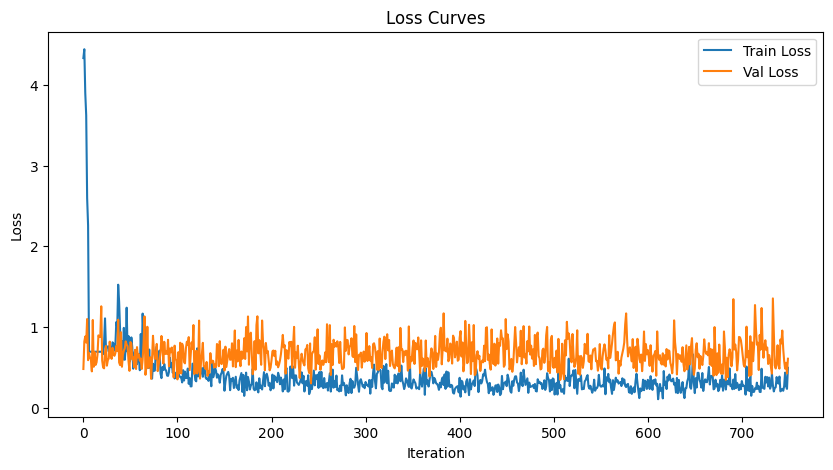

In [128]:
fig = plt.figure(facecolor="w", figsize=(10, 5))

# plot for a single epoch training and validation loss - num_steps=4, batches=40


# get train and val loss for 1 epoch
train_loss = history["train"]["loss"][:750]
val_loss = history["val"]["loss"][:750]

# print(len(train_loss), len(val_loss))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")

# draw a vertical line at the end of the first epoch
# plt.axvline(x=len(train_loss)//2, color="r", linestyle="--")



plt.title("Loss Curves")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [129]:
# checkpoint = torch.load(savepath, weights_only=False)
# best_model = BasicSNN().to(device)
# best_model.load_state_dict(checkpoint['model_state_dict'])

checkpoint = torch.load(savepath, weights_only=False)
best_model = BasicSNN(num_steps=8).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [130]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

# shuffle the data
test_data_sample = test_data_sample.sample(frac=1, random_state=42).reset_index(drop=True) 

test_dataset_sample = CustomDatasetSpike(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [131]:
def calculate_accuracy2(model, test_data_loader_sample, device, class_names=None):
    y_true = torch.tensor([], dtype=torch.long, device=device)
    y_pred = torch.tensor([], dtype=torch.long, device=device)

    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0

        for images, labels in tqdm(test_data_loader_sample, desc="Calculating Accuracy"):
            images, labels = images.to(device), labels.to(device)
            utils.reset(model)  # Reset neuron states per batch

            spk_rec, _ = model(images)  # Shape: [num_steps, batch_size, num_classes]
            # spk_mean = spk_rec.sum(dim=0)  # Sum spikes over time
            # preds = spk_mean.argmax(dim=1)  # Get predictions
            preds = get_predictions_from_spikes(spk_rec)

            # Append predictions and labels
            y_true = torch.cat((y_true, labels))
            y_pred = torch.cat((y_pred, preds))

            # Compute batch accuracy
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        # Convert to numpy arrays only once
        y_true = y_true.cpu().numpy()
        y_pred = y_pred.cpu().numpy()

        # Compute overall accuracy
        acc = correct / total
        print(f"Accuracy: {acc:.4f}")

    return y_true, y_pred



y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_sample, device=device)


Calculating Accuracy:   0%|          | 0/300 [00:00<?, ?it/s]

Calculating Accuracy: 100%|██████████| 300/300 [00:32<00:00,  9.16it/s]

Accuracy: 0.9473


              precision    recall  f1-score   support

   Malicious       0.98      0.91      0.95      6000
      Benign       0.92      0.98      0.95      6000

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



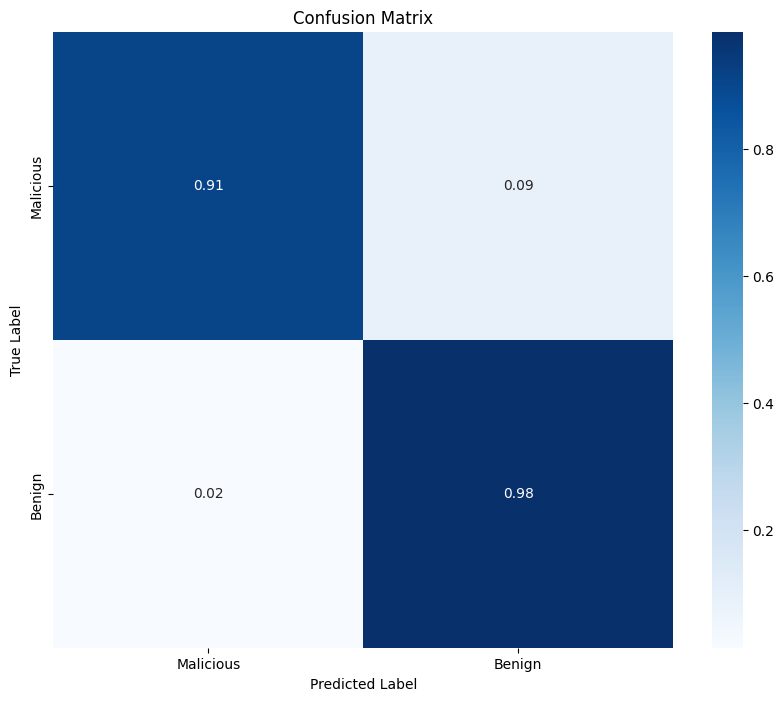

In [132]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_cm(y_true, y_pred, classes, normalize=False):
    """Plot confusion matrix."""

    classification_rep = classification_report(y_true, y_pred, target_names=classes)
    print(classification_rep)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)), normalize='true' if normalize else None)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Plot confusion matrix
plot_cm(y_true, y_pred, LE.classes_, normalize=True)

In [ ]:
# create a popup notification when the notebook run is complete
import os
os.system("notify-send 'Notebook run complete'")
